## 07 Xenium Transcriptional Trends Along Pseudotime

**What this notebook does:** Demonstrates the value of morphology-based niche pseudotime in Xenium spatial transcriptomics by showing:

1. **Gene expression trends** — per-gene LOWESS trends of ductal identity, PanIN/ADM, and proliferation markers along the niche pseudotime axis
2. **Surround cell-type activation trends** — how fibroblast activation state (ACTA2, PDGFRA, DCN), T-cell functional state (CD8A, FOXP3, GZMB), and myeloid polarisation (CD163, S100A9) change along the trajectory
3. **Pseudo-ligand–receptor proxies** — niche-level ductal ligand expression paired with surrounding-cell receptor expression to infer directional communication along pseudotime
4. **Cross-modality concordance** — IMC (protein) vs Xenium (transcript) pseudotime clinical-stage ordering side by side

All analyses use pre-computed per-niche features — no re-loading of raw h5ad files required.


In [1]:
# DATA AVAILABILITY CHECK
from pathlib import Path
import os
_output_dir = Path("/Users/shihongwu/SpatioEv") / "data" / "xenium_pancreas_10x"
_pseudotime_dir = _output_dir / "pseudotime"
_required = [_output_dir, _pseudotime_dir / "xenium_pseudotime_result_df.pkl"]
_missing = [f for f in _required if not os.path.exists(f)]
if _missing:
    print(f'Missing: {_missing}')
    print('Run notebooks 00–03 first.')
else:
    print('All required data found. Notebook is ready to run.')


All required data found. Notebook is ready to run.


## Setup

In [2]:

%matplotlib inline
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba")

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

ROOT       = Path("/Users/shihongwu/SpatioEv")
OUTPUT_DIR = ROOT / "data" / "xenium_pancreas_10x"
NICHE_DIR  = OUTPUT_DIR / "niche_features"
PT_DIR     = OUTPUT_DIR / "pseudotime"
FIG_DIR    = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

# Nature/Cell rcParams
_pub_rc = {
    "font.family": "sans-serif", "font.sans-serif": ["Arial","Helvetica","DejaVu Sans"],
    "font.size": 7, "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": "white", "figure.facecolor": "white",
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,
}
mpl.rcParams.update(_pub_rc)

DISEASE_PALETTE = {"NormalPancreas": "#4CAF50", "PDAC": "#D32F2F"}
SAMPLE_PALETTE  = {
    "normal_nondiseased_v1": "#4CAF50",
    "pdac_addon_v1":         "#7B1FA2",
    "pdac_io_v1":            "#1565C0",
    "pdac_pancreas_v1":      "#E65100",
}
CLINICAL_ORDER = ["Normal pancreas","Grade I-II, 50% tumor","Stage III adenocarcinoma","Stage IIB, Grade 3 PDAC"]
CLINICAL_PALETTE = dict(zip(CLINICAL_ORDER, ["#4CAF50","#7B1FA2","#E65100","#1565C0"]))

NICHE_KEY = "xenium_ductal_epithelium_component"

SAMPLE_CONFIGS = [
    {"sample_id": "pdac_pancreas_v1",      "disease_group": "PDAC",          "panel": "Multi-Tissue"},
    {"sample_id": "pdac_io_v1",            "disease_group": "PDAC",          "panel": "IO"},
    {"sample_id": "pdac_addon_v1",         "disease_group": "PDAC",          "panel": "Multi-Tissue+Add-on"},
    {"sample_id": "normal_nondiseased_v1", "disease_group": "NormalPancreas", "panel": "Multi-Tissue"},
]

def lowess_smooth(x, y, frac=0.3):
    tmp = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    if len(tmp) < 15 or tmp["x"].nunique() < 8:
        return None
    if tmp["y"].std() < 1e-8:
        return None
    return sm.nonparametric.lowess(tmp["y"], tmp["x"], frac=frac, return_sorted=True)

print("Setup complete.")


Setup complete.


## Load data

In [3]:

# ── Load pseudotime result and pooled niche feature table ─────────────────────
result_df = pd.read_pickle(PT_DIR / "xenium_pseudotime_result_df.pkl")

# Load per-sample niche feature tables and concatenate
sample_feature_frames = []
sample_surround_frames = []
for cfg in SAMPLE_CONFIGS:
    sid = cfg["sample_id"]
    feat = pd.read_pickle(NICHE_DIR / f"{sid}_niche_feature_df.pkl")
    feat["sample_id"]     = sid
    feat["disease_group"] = cfg["disease_group"]
    feat["panel"]         = cfg["panel"]
    surr = pd.read_pickle(NICHE_DIR / f"{sid}_surround_context_df.pkl")
    surr["sample_id"]     = sid
    sample_feature_frames.append(feat)
    sample_surround_frames.append(surr)

pooled_feat_df = pd.concat(sample_feature_frames, ignore_index=True, sort=False)
pooled_surr_df = pd.concat(sample_surround_frames, ignore_index=True, sort=False)

# Merge pseudotime into feature df via niche key + sample
result_key = result_df[[NICHE_KEY, "sample_id", "disease_group",
                         "xenium_pseudotime", "xenium_pseudotime_norm",
                         "major_branch", "clinical_progression_label",
                         "clinical_progression_order"]].copy()
analysis_df = pooled_feat_df.merge(
    result_key, on=[NICHE_KEY, "sample_id", "disease_group"], how="inner"
)
analysis_surr_df = pooled_surr_df.merge(
    result_key, on=[NICHE_KEY, "sample_id", "disease_group"], how="inner"
)

print(f"Feature df: {analysis_df.shape}")
print(f"Surround df: {analysis_surr_df.shape}")
display(analysis_df.groupby(["sample_id","disease_group","panel"]).size().rename("n_niches").reset_index())


Feature df: (5074, 2157)
Surround df: (5074, 240)


,sample_id,disease_group,panel,n_niches
0,normal_nondiseased_v1,NormalPancreas,Multi-Tissue,1777
1,pdac_addon_v1,PDAC,Multi-Tissue+Add-on,1215
2,pdac_io_v1,PDAC,IO,587
3,pdac_pancreas_v1,PDAC,Multi-Tissue,1495


## Stage 1. Gene expression trends along pseudotime

Per-niche mean z-scored expression (`state__GENE_expr_z__mean`) of key marker genes plotted along the Xenium niche pseudotime.  

**Panel strategy:** genes shared by all four panels are shown cross-sample; panel-specific genes are shown for the relevant samples only.


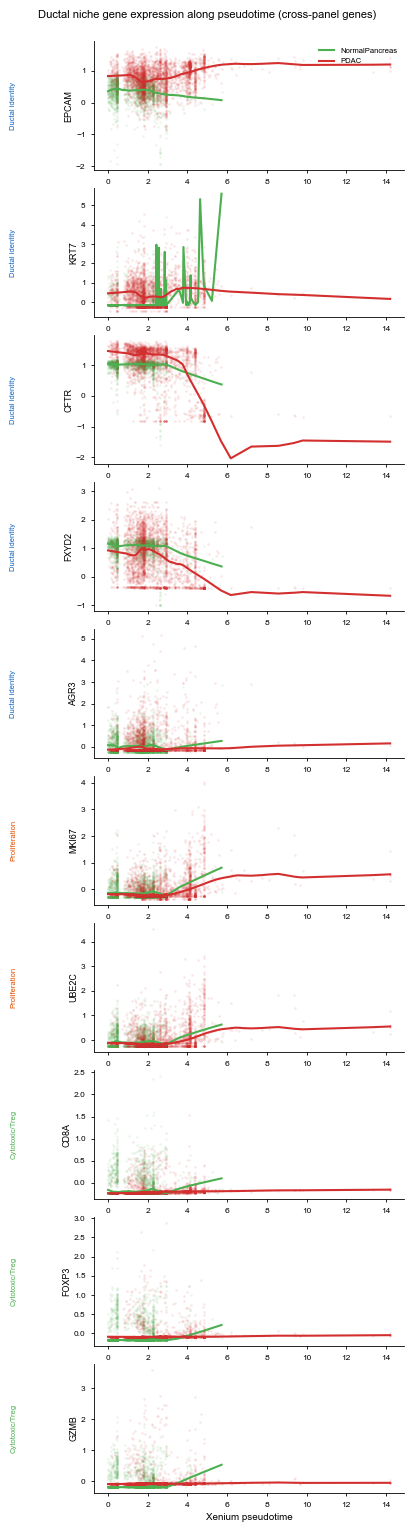

Panel A: common genes plotted.


In [4]:

# ── Define gene groups ────────────────────────────────────────────────────────
# Common across all panels
COMMON_DUCTAL  = ["EPCAM", "KRT7", "CFTR", "FXYD2", "AGR3"]  # normal duct identity
COMMON_PROLIF  = ["MKI67", "UBE2C"]                             # proliferation
COMMON_IMMUNE  = ["CD8A", "FOXP3", "GZMB"]                     # cytotoxic/Treg

# Panel-specific (Multi-Tissue panel: pdac_pancreas, normal, pdac_addon)
MT_PANIN       = ["TFF2", "PROX1", "DMBT1"]                    # PanIN/ADM remodeling

# Panel-specific (IO panel: pdac_io)
IO_PANIN       = ["MUC5AC", "TFF3", "CEACAM6", "SOX9"]        # PanIN/ADM remodeling
IO_CHECKPOINT  = ["CD274"]                                       # immune checkpoint (PD-L1)

def state_col(gene): return f"state__{gene}_expr_z__mean"

def plot_gene_trends(df, gene_groups, group_labels, n_cols=3, frac=0.35,
                     pt_col="xenium_pseudotime", title_prefix=""):
    all_genes = [g for genes in gene_groups for g in genes]
    n_rows = len(all_genes)
    fig, axes = plt.subplots(n_rows, n_cols if n_cols>1 else 1,
                             figsize=(2.8*max(n_cols,1), 1.6*n_rows),
                             sharey=False, sharex=False)
    if n_rows == 1: axes = [axes]
    for row_idx, gene in enumerate(all_genes):
        col = state_col(gene)
        ax = axes[row_idx] if n_cols <= 1 else axes[row_idx]
        if col not in df.columns:
            if n_cols > 1:
                for a in axes[row_idx]: a.set_visible(False)
            else:
                axes[row_idx].set_visible(False)
            continue
        ax_ref = axes[row_idx] if n_cols <= 1 else axes[row_idx][0]
        # Plot each disease group
        for disease, color in DISEASE_PALETTE.items():
            sub = df[df["disease_group"] == disease]
            if len(sub) < 10: continue
            ax_ref.scatter(sub[pt_col], sub[col], s=3, alpha=0.12, c=color,
                          linewidths=0, rasterized=True)
            smooth = lowess_smooth(sub[pt_col], sub[col], frac=frac)
            if smooth is not None:
                ax_ref.plot(smooth[:,0], smooth[:,1], color=color, lw=1.5, zorder=3)
        ax_ref.set_ylabel(gene, fontsize=6.5, labelpad=2)
        for sp in ["top","right"]: ax_ref.spines[sp].set_visible(False)
        if row_idx == len(all_genes)-1:
            ax_ref.set_xlabel("Xenium pseudotime", fontsize=7)
    fig.suptitle(title_prefix, fontsize=8, y=1.01)
    return fig

# ── Plot 1: Cross-panel genes ─────────────────────────────────────────────────
fig1, axes = plt.subplots(len(COMMON_DUCTAL)+len(COMMON_PROLIF)+len(COMMON_IMMUNE), 1,
                           figsize=(4.0, 1.5*(len(COMMON_DUCTAL)+len(COMMON_PROLIF)+len(COMMON_IMMUNE))),
                           sharex=False)

all_common = (
    [("Ductal identity", g) for g in COMMON_DUCTAL] +
    [("Proliferation", g) for g in COMMON_PROLIF] +
    [("Cytotoxic/Treg", g) for g in COMMON_IMMUNE]
)
group_colors = {"Ductal identity": "#1565C0", "Proliferation": "#E65100", "Cytotoxic/Treg": "#4CAF50"}

for ax, (group, gene) in zip(axes, all_common):
    col = state_col(gene)
    if col not in analysis_df.columns:
        ax.set_visible(False)
        continue
    for disease, color in DISEASE_PALETTE.items():
        sub = analysis_df[analysis_df["disease_group"] == disease]
        if len(sub) < 10: continue
        ax.scatter(sub["xenium_pseudotime"], sub[col], s=3, alpha=0.12, c=color,
                   linewidths=0, rasterized=True)
        smooth = lowess_smooth(sub["xenium_pseudotime"], sub[col])
        if smooth is not None:
            ax.plot(smooth[:,0], smooth[:,1], color=color, lw=1.5, zorder=3)
    ax.set_ylabel(gene, fontsize=6.5, labelpad=2)
    ax.text(-0.25, 0.5, group, transform=ax.transAxes, fontsize=5.5, color=group_colors.get(group,"#333"),
            rotation=90, va="center", ha="right")
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)

axes[-1].set_xlabel("Xenium pseudotime", fontsize=7)

# Legend
from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], color=c, lw=1.5, label=d) for d, c in DISEASE_PALETTE.items()]
axes[0].legend(handles=legend_handles, frameon=False, fontsize=5.5, loc="upper right")

fig1.suptitle("Ductal niche gene expression along pseudotime (cross-panel genes)", fontsize=8, y=1.01)
plt.tight_layout(pad=0.3, h_pad=0.2)
plt.savefig(FIG_DIR / "fig_gene_trends_common.pdf")
plt.show()
print("Panel A: common genes plotted.")


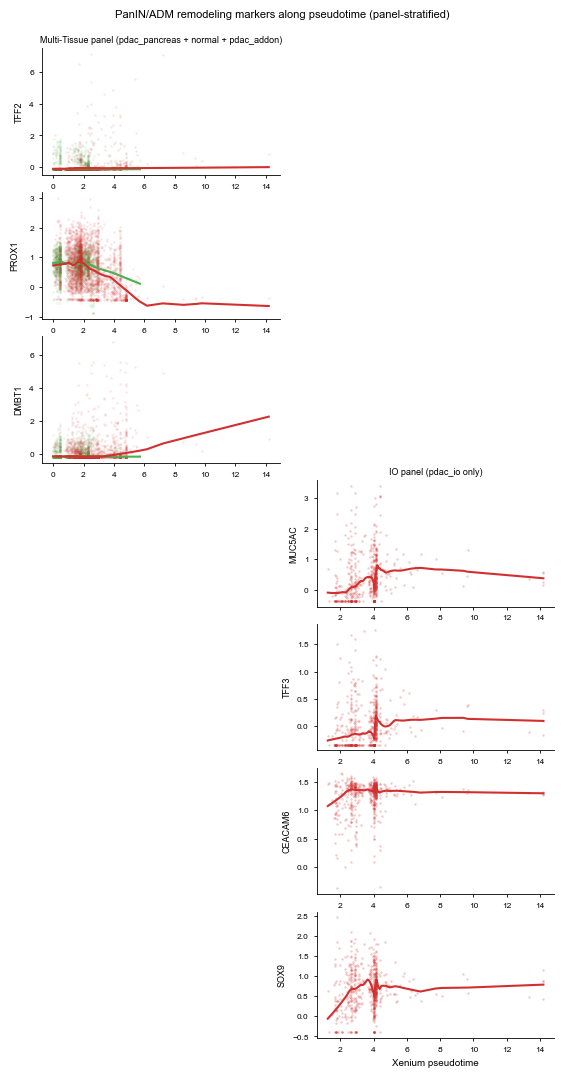

In [5]:

# ── Plot 2: Multi-Tissue panel PanIN/ADM genes (3 samples) ───────────────────
mt_df   = analysis_df[analysis_df["panel"].str.startswith("Multi-Tissue")]
io_df   = analysis_df[analysis_df["sample_id"] == "pdac_io_v1"]

fig2, axes = plt.subplots(len(MT_PANIN) + len(IO_PANIN), 2,
                           figsize=(5.5, 1.5*(len(MT_PANIN)+len(IO_PANIN))),
                           sharey=False)

for row, gene in enumerate(MT_PANIN):
    col = state_col(gene)
    for (ax, df_, label) in [(axes[row,0], mt_df, "Multi-Tissue panel (pdac_pancreas + normal + pdac_addon)")]:
        if col not in df_.columns:
            ax.set_visible(False)
            continue
        for disease, color in DISEASE_PALETTE.items():
            sub = df_[df_["disease_group"] == disease]
            if len(sub) < 10: continue
            ax.scatter(sub["xenium_pseudotime"], sub[col], s=3, alpha=0.12, c=color,
                       linewidths=0, rasterized=True)
            _sm = lowess_smooth(sub["xenium_pseudotime"], sub[col])
            if _sm is not None: ax.plot(_sm[:,0], _sm[:,1], color=color, lw=1.5, zorder=3)
        ax.set_ylabel(gene, fontsize=6.5)
        if row == 0: ax.set_title(label, fontsize=6.5, pad=4)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    axes[row,1].set_visible(False)

for row_off, gene in enumerate(IO_PANIN):
    row = len(MT_PANIN) + row_off
    col = state_col(gene)
    for (ax, df_, label) in [(axes[row,1], io_df, "IO panel (pdac_io only)")]:
        if col not in df_.columns:
            ax.set_visible(False)
            continue
        sub_pdac = df_[df_["disease_group"] == "PDAC"]
        ax.scatter(sub_pdac["xenium_pseudotime"], sub_pdac[col], s=3, alpha=0.25,
                   c=DISEASE_PALETTE["PDAC"], linewidths=0, rasterized=True)
        _sm = lowess_smooth(sub_pdac["xenium_pseudotime"], sub_pdac[col])
        if _sm is not None: ax.plot(_sm[:,0], _sm[:,1], color=DISEASE_PALETTE["PDAC"], lw=1.5)
        ax.set_ylabel(gene, fontsize=6.5)
        if row_off == 0: ax.set_title(label, fontsize=6.5, pad=4)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    axes[row,0].set_visible(False)

for c in [0,1]: axes[-1,c].set_xlabel("Xenium pseudotime", fontsize=7)

fig2.suptitle("PanIN/ADM remodeling markers along pseudotime (panel-stratified)", fontsize=8, y=1.01)
plt.tight_layout(pad=0.3)
plt.savefig(FIG_DIR / "fig_gene_trends_panin.pdf")
plt.show()


## Stage 2. Surround cell-type activation along pseudotime

Each row is a functional marker of a surrounding cell type. These are **proxy interaction readouts**: they show how the state of cells in contact with each ductal niche changes along the progression trajectory — directly from the niche graph without running a separate CCI tool.


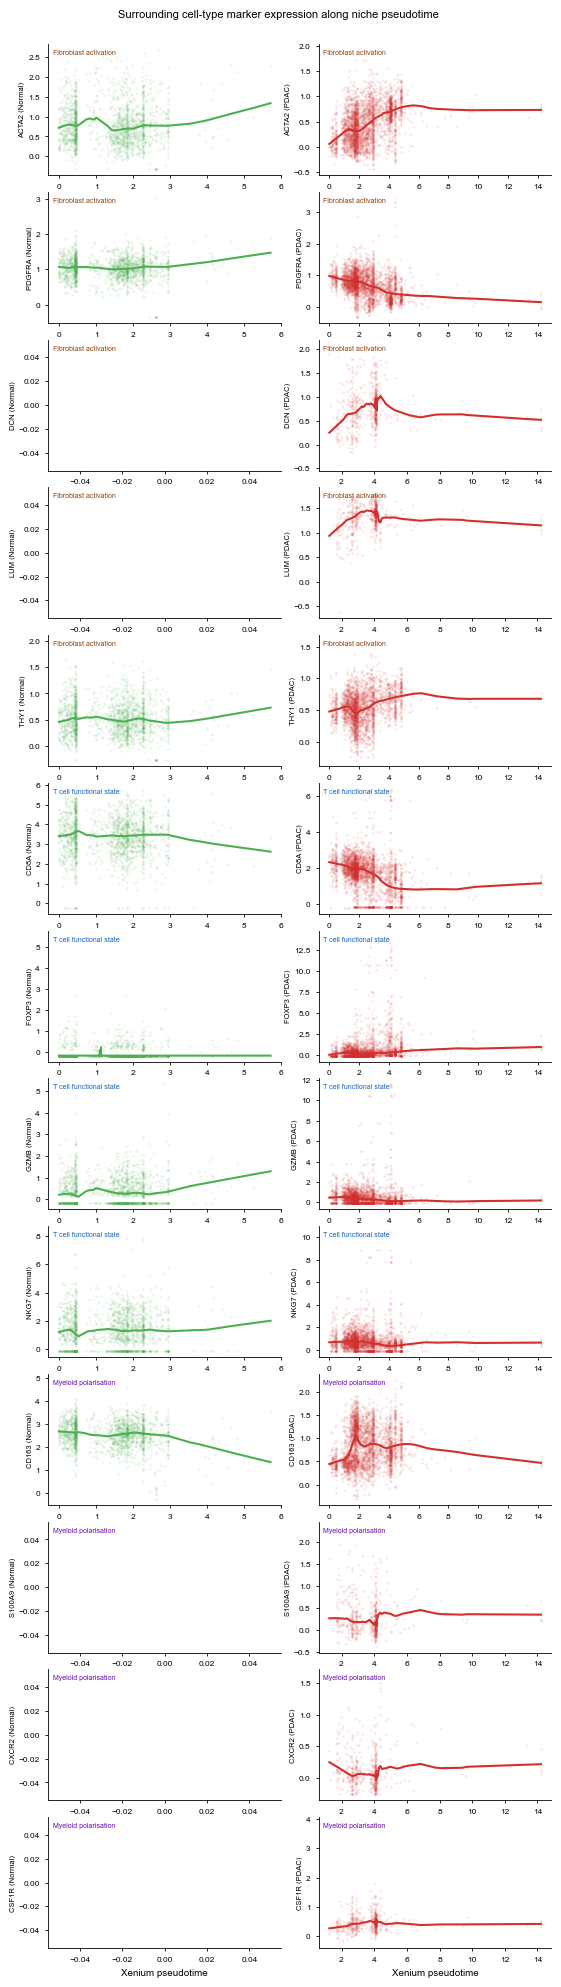

In [6]:

# ── Define surround marker groups ─────────────────────────────────────────────
FIBRO_MARKERS = {
    "ACTA2": "surround__Fibroblasts__ACTA2_expr_z__mean",    # myofibroblast / CAF
    "PDGFRA": "surround__Fibroblasts__PDGFRA_expr_z__mean",  # progenitor fibroblast
    "DCN":   "surround__Fibroblasts__DCN_expr_z__mean",      # matrix-remodelling
    "LUM":   "surround__Fibroblasts__LUM_expr_z__mean",      # lumican / CAF
    "THY1":  "surround__Fibroblasts__THY1_expr_z__mean",     # quiescent fibroblast
}
TCELL_MARKERS = {
    "CD8A":  "surround__T_cells__CD8A_expr_z__mean",
    "FOXP3": "surround__T_cells__FOXP3_expr_z__mean",
    "GZMB":  "surround__T_cells__GZMB_expr_z__mean",
    "NKG7":  "surround__T_cells__NKG7_expr_z__mean",
}
MYELOID_MARKERS = {
    "CD163":  "surround__Myeloid_cells__CD163_expr_z__mean",  # M2 TAM
    "S100A9": "surround__Myeloid_cells__S100A9_expr_z__mean", # inflammatory myeloid
    "CXCR2":  "surround__Myeloid_cells__CXCR2_expr_z__mean",  # neutrophil
    "CSF1R":  "surround__Myeloid_cells__CSF1R_expr_z__mean",  # monocyte/macrophage
}

all_surround_groups = [
    ("Fibroblast activation", FIBRO_MARKERS, "#8B4513"),
    ("T cell functional state", TCELL_MARKERS, "#1565C0"),
    ("Myeloid polarisation", MYELOID_MARKERS, "#6A0DAD"),
]

n_total = sum(len(m) for _, m, _ in all_surround_groups)
fig, axes = plt.subplots(n_total, 2, figsize=(5.5, 1.5*n_total), sharey=False)
axes = axes.reshape(n_total, 2)

row = 0
for group_label, markers, group_color in all_surround_groups:
    for marker_name, col in markers.items():
        if col not in analysis_surr_df.columns:
            axes[row,0].set_visible(False); axes[row,1].set_visible(False)
            row += 1; continue
        for col_idx, (disease, color) in enumerate(DISEASE_PALETTE.items()):
            ax = axes[row, col_idx]
            sub = analysis_surr_df[analysis_surr_df["disease_group"] == disease]
            if len(sub) < 10:
                ax.set_visible(False); continue
            ax.scatter(sub["xenium_pseudotime"], sub[col], s=3, alpha=0.12, c=color,
                       linewidths=0, rasterized=True)
            smooth = lowess_smooth(sub["xenium_pseudotime"], sub[col])
            if smooth is not None:
                ax.plot(smooth[:,0], smooth[:,1], color=color, lw=1.5, zorder=3)
            ax.set_ylabel(f"{marker_name} ({disease[:6]})", fontsize=5.5, labelpad=2)
            ax.text(0.02, 0.92, group_label, transform=ax.transAxes, fontsize=5, color=group_color)
            for sp in ["top","right"]: ax.spines[sp].set_visible(False)
            if row == n_total-1: ax.set_xlabel("Xenium pseudotime", fontsize=7)
        row += 1

fig.suptitle("Surrounding cell-type marker expression along niche pseudotime", fontsize=8, y=1.01)
plt.tight_layout(pad=0.2, h_pad=0.15)
plt.savefig(FIG_DIR / "fig_surround_trends.pdf")
plt.show()


## Stage 3. Heatmap summary — gene expression and surround activation per pseudotime bin

Aggregate all marker trends into a compact heatmap: rows = marker genes / surround markers, columns = pseudotime bins (deciles), colour = mean z-score per bin.


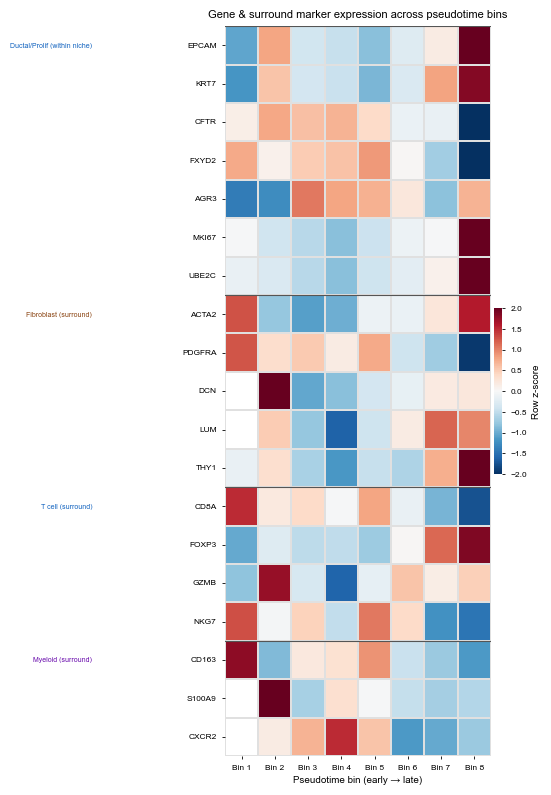

In [7]:

# ── Pseudotime bin heatmap — ductal niche genes + surround markers ─────────────
N_BINS = 8

# Bin pseudotime
analysis_df["pt_bin"] = pd.qcut(
    analysis_df["xenium_pseudotime"], q=N_BINS, labels=False, duplicates="drop"
)
analysis_surr_df["pt_bin"] = pd.qcut(
    analysis_surr_df["xenium_pseudotime"], q=N_BINS, labels=False, duplicates="drop"
)

# Collect markers and their sources
heatmap_entries = []

# Within-niche ductal genes
for gene in COMMON_DUCTAL + COMMON_PROLIF:
    col = state_col(gene)
    if col in analysis_df.columns:
        heatmap_entries.append(("Ductal/Prolif (within niche)", gene, analysis_df, col))

# Surround fibroblast
for g, col in FIBRO_MARKERS.items():
    if col in analysis_surr_df.columns:
        heatmap_entries.append(("Fibroblast (surround)", g, analysis_surr_df, col))

# Surround T cell
for g, col in TCELL_MARKERS.items():
    if col in analysis_surr_df.columns:
        heatmap_entries.append(("T cell (surround)", g, analysis_surr_df, col))

# Surround myeloid
for g, col in list(MYELOID_MARKERS.items())[:3]:
    if col in analysis_surr_df.columns:
        heatmap_entries.append(("Myeloid (surround)", g, analysis_surr_df, col))

# Build heatmap matrix
bin_means = {}
for group, gene, df_, col in heatmap_entries:
    bin_means[f"{group}|{gene}"] = df_.groupby("pt_bin", observed=True)[col].mean()

heatmap_df = pd.DataFrame(bin_means).T
heatmap_df.columns = [f"Bin {int(c)+1}" for c in heatmap_df.columns]
# z-score rows for visual contrast
heatmap_z = (heatmap_df.T - heatmap_df.T.mean()) / heatmap_df.T.std().replace(0,1)
heatmap_z = heatmap_z.T

# Row colour annotation
row_groups = [e[0] for e in heatmap_entries]
group_color_map = {
    "Ductal/Prolif (within niche)": "#1565C0",
    "Fibroblast (surround)": "#8B4513",
    "T cell (surround)": "#1565C0",
    "Myeloid (surround)": "#6A0DAD",
}
row_colors = pd.Series([group_color_map.get(g,"#888") for g in row_groups],
                        index=[f"{e[0]}|{e[1]}" for e in heatmap_entries],
                        name="Group")

fig_h, ax_h = plt.subplots(figsize=(6.5, 0.35*len(heatmap_z)+1.2))
sns.heatmap(
    heatmap_z,
    cmap="RdBu_r", center=0, vmin=-2, vmax=2,
    linewidths=0.15, linecolor="#e0e0e0",
    ax=ax_h,
    cbar_kws={"shrink": 0.5, "label": "Row z-score", "fraction": 0.03, "pad": 0.01},
)
# Clean up row labels
yticklabels = [lbl.split("|")[1] for lbl in heatmap_z.index]
ax_h.set_yticklabels(yticklabels, fontsize=6, rotation=0)
ax_h.set_xticklabels(ax_h.get_xticklabels(), fontsize=6)
ax_h.set_xlabel("Pseudotime bin (early → late)", fontsize=7)
ax_h.set_title("Gene & surround marker expression across pseudotime bins", fontsize=8, pad=6)

# Group delimiters
prev_group = None
for i, (g, gene, _, _) in enumerate(heatmap_entries):
    if g != prev_group:
        ax_h.axhline(i, color="#555", lw=0.8)
        ax_h.text(-0.5, i + 0.5, g.replace("\n"," "), fontsize=5, ha="right",
                  va="center", color=group_color_map.get(g,"#888"), transform=ax_h.get_yaxis_transform())
        prev_group = g

plt.tight_layout(pad=0.5)
plt.savefig(FIG_DIR / "fig_pseudotime_bin_heatmap.pdf")
plt.show()


## Stage 4. Cross-modality concordance — IMC (protein) vs Xenium (transcript)

The key methodological claim is that morphology-based niche pseudotime generalises across measurement modalities. Here we show that both IMC and Xenium trajectories order clinical disease stages identically, even though they are built from different data types (protein fluorescence vs transcript counts).


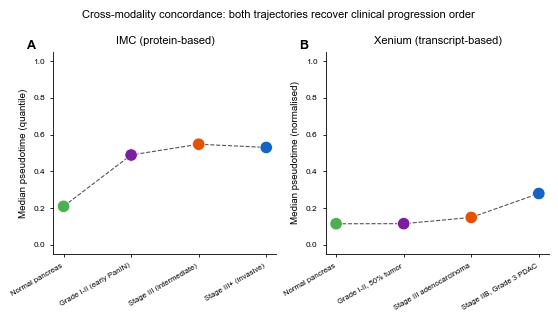

Pearson correlation (stage order vs median pseudotime):
  IMC:    r=0.832, p=0.1677
  Xenium: r=0.871, p=0.1285


In [8]:

# ── Cross-modality concordance ────────────────────────────────────────────────
# IMC pseudotime data: from the combined IMC notebook results
IMC_RESULT_PATH = ROOT / "data" / "combined_exp_2_3_4_5" / "pooled_niche_result_df.pkl"
IMC_LABEL_MAP   = {
    "NormalPancreas":  ("Normal pancreas",           0, "#4CAF50"),
    "PDAC_exp_4":      ("Grade I-II (early PanIN)",  1, "#7B1FA2"),
    "PDAC_exp_3":      ("Stage III (intermediate)",  2, "#E65100"),
    "PDAC_exp_2":      ("Stage III+ (invasive)",     3, "#1565C0"),
}

if not IMC_RESULT_PATH.exists():
    print("IMC result not found — skipping cross-modality plot.")
else:
    imc_df = pd.read_pickle(IMC_RESULT_PATH)

    # IMC: median pooled_pseudotime_q per differentiation label
    imc_pt = (
        imc_df.groupby("differentiation_label")["pooled_pseudotime_q"]
        .median()
        .reset_index()
    )
    imc_pt["modality"]  = "IMC (protein)"
    imc_pt["label"] = imc_pt["differentiation_label"].map(
        {k: v[0] for k, v in IMC_LABEL_MAP.items()}
    )
    imc_pt["order"] = imc_pt["differentiation_label"].map(
        {k: v[1] for k, v in IMC_LABEL_MAP.items()}
    )
    imc_pt["color"] = imc_pt["differentiation_label"].map(
        {k: v[2] for k, v in IMC_LABEL_MAP.items()}
    )
    imc_pt = imc_pt.dropna().sort_values("order")

    # Xenium: median xenium_pseudotime_norm + order per clinical label (single groupby)
    xen_pt = (
        result_df.groupby("clinical_progression_label", as_index=False)
        .agg(
            xenium_pseudotime_norm=("xenium_pseudotime_norm", "median"),
            order=("clinical_progression_order", "median"),
        )
    )
    xen_pt["modality"] = "Xenium (transcript)"
    xen_pt = xen_pt.dropna(subset=["order", "xenium_pseudotime_norm"]).sort_values("order")
    xen_pt["color"] = xen_pt["clinical_progression_label"].map(CLINICAL_PALETTE)

    fig, axes = plt.subplots(1, 2, figsize=(5.5, 3.0))

    # IMC panel
    ax = axes[0]
    ax.scatter(imc_pt["order"], imc_pt["pooled_pseudotime_q"],
               c=imc_pt["color"], s=80, zorder=3, edgecolors="white", linewidths=0.5)
    ax.plot(imc_pt["order"], imc_pt["pooled_pseudotime_q"],
            color="#555", lw=0.8, zorder=2, linestyle="--")
    ax.set_xticks(imc_pt["order"])
    ax.set_xticklabels(imc_pt["label"], rotation=30, ha="right", fontsize=5.5)
    ax.set_ylabel("Median pseudotime (quantile)", fontsize=7)
    ax.set_title("IMC (protein-based)", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)

    # Xenium panel
    ax = axes[1]
    ax.scatter(xen_pt["order"], xen_pt["xenium_pseudotime_norm"],
               c=xen_pt["color"], s=80, zorder=3, edgecolors="white", linewidths=0.5)
    ax.plot(xen_pt["order"], xen_pt["xenium_pseudotime_norm"],
            color="#555", lw=0.8, zorder=2, linestyle="--")
    ax.set_xticks(xen_pt["order"])
    ax.set_xticklabels(xen_pt["clinical_progression_label"], rotation=30, ha="right", fontsize=5.5)
    ax.set_ylabel("Median pseudotime (normalised)", fontsize=7)
    ax.set_title("Xenium (transcript-based)", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)

    for ax, lbl in zip(axes, "AB"):
        ax.text(-0.12, 1.06, lbl, transform=ax.transAxes,
                fontsize=9, fontweight="bold", va="top")

    fig.suptitle("Cross-modality concordance: both trajectories recover clinical progression order",
                 fontsize=8, y=1.02)
    plt.tight_layout(pad=0.5)
    plt.savefig(FIG_DIR / "fig_crossmodality_concordance.pdf")
    plt.show()
    print("Pearson correlation (stage order vs median pseudotime):")
    from scipy.stats import pearsonr
    r_imc, p_imc = pearsonr(imc_pt["order"], imc_pt["pooled_pseudotime_q"])
    _xen_clean = xen_pt.dropna(subset=["order", "xenium_pseudotime_norm"])
    r_xen, p_xen = pearsonr(_xen_clean["order"], _xen_clean["xenium_pseudotime_norm"])
    print(f"  IMC:    r={r_imc:.3f}, p={p_imc:.4f}")
    print(f"  Xenium: r={r_xen:.3f}, p={p_xen:.4f}")


## Stage 5. Export data for SpatialCellChat (R)

The cell below exports per-sample data in the CSV format required by the R script `07_xenium_05_spatialcellchat.R`.  
Run the R script after this step, then load results in `07_xenium_06_cellchat_integration.ipynb`.


In [9]:
import scanpy as sc
# ── Export data for SpatialCellChat ───────────────────────────────────────────
# Uses _with_niches.h5ad (written by notebook 02) which contains the
# xenium_ductal_epithelium_component column per cell — enabling accurate
# niche centroid computation and pseudotime bin assignment per cell.

import scipy.sparse as sp_sparse
CELLCHAT_DIR = OUTPUT_DIR / "spatialcellchat"
CELLCHAT_DIR.mkdir(exist_ok=True)

common_genes_df = pd.read_csv(OUTPUT_DIR / "xenium_common_genes.csv")
COMMON_GENES = common_genes_df["gene"].tolist()
print(f"Common genes for export: {len(COMMON_GENES)}")

# Pseudotime bin assignment at niche level
N_PT_BINS = 5
result_df["pt_bin_cellchat"] = pd.qcut(
    result_df["xenium_pseudotime_norm"], q=N_PT_BINS,
    labels=[f"bin{i+1}" for i in range(N_PT_BINS)], duplicates="drop"
)
niche_pt_map = result_df[[NICHE_KEY, "sample_id", "xenium_pseudotime",
                            "xenium_pseudotime_norm", "pt_bin_cellchat",
                            "major_branch", "clinical_progression_label"]].copy()
niche_pt_map.to_csv(CELLCHAT_DIR / "niche_pseudotime_bins.csv", index=False)
print(f"Niche pseudotime bin map: {len(niche_pt_map)} niches")
print(result_df["pt_bin_cellchat"].value_counts().sort_index())

exported = []
niche_centroids_all = []

for cfg in SAMPLE_CONFIGS:
    sid = cfg["sample_id"]
    # Prefer _with_niches.h5ad (has xenium_ductal_epithelium_component per cell)
    # Fall back to _annotated.h5ad if needed
    adata_path = OUTPUT_DIR / "niche_features" / f"{sid}_with_niches.h5ad"
    if not adata_path.exists():
        adata_path = OUTPUT_DIR / "annotated_h5ad" / f"{sid}_annotated.h5ad"
    if not adata_path.exists():
        print(f"  {sid}: no h5ad found — skip")
        continue

    adata = sc.read_h5ad(adata_path)
    print(f"  {sid}: {adata.n_obs} cells, obs cols: {[c for c in adata.obs.columns if 'centroid' in c.lower() or 'ductal' in c.lower() or 'Tier' in c][:10]}")

    # Build cell metadata
    coord_cols  = [c for c in ["x_centroid","y_centroid","X_centroid","Y_centroid"] if c in adata.obs.columns]
    tier_cols   = [c for c in ["Tier_A","Tier_B"] if c in adata.obs.columns]
    niche_col   = next((c for c in adata.obs.columns
                        if "ductal" in c.lower() and "component" in c.lower()), None)
    keep_cols   = coord_cols[:2] + tier_cols + ([niche_col] if niche_col else [])
    meta = adata.obs[keep_cols].copy()
    if coord_cols:
        meta = meta.rename(columns={coord_cols[0]: "x", coord_cols[1]: "y"})
    if niche_col:
        meta = meta.rename(columns={niche_col: "niche_id"})
    meta.index.name = "cell_id"
    meta = meta.reset_index()

    # Merge niche pseudotime
    if "niche_id" in meta.columns:
        meta = meta.merge(
            niche_pt_map[niche_pt_map["sample_id"] == sid][[NICHE_KEY, "xenium_pseudotime_norm", "pt_bin_cellchat"]],
            left_on="niche_id", right_on=NICHE_KEY, how="left"
        ).drop(columns=[NICHE_KEY])

        # Compute niche centroids for R spatial lookup (fallback)
        if "x" in meta.columns and "y" in meta.columns:
            niche_cent = (
                meta.dropna(subset=["niche_id","x","y"])
                .groupby("niche_id")[["x","y"]].mean()
                .reset_index()
                .rename(columns={"niche_id": NICHE_KEY, "x":"niche_x", "y":"niche_y"})
            )
            niche_cent["sample_id"] = sid
            niche_cent = niche_cent.merge(
                niche_pt_map[niche_pt_map["sample_id"]==sid][[NICHE_KEY,"pt_bin_cellchat"]],
                on=NICHE_KEY, how="left"
            )
            niche_centroids_all.append(niche_cent)
            print(f"    Niche centroids: {len(niche_cent)} niches with x/y")

    meta_path = CELLCHAT_DIR / f"{sid}_cell_meta.csv"
    meta.to_csv(meta_path, index=False)

    # Count matrix — export ALL genes for this sample (full panel for CellChat L-R matching)
    # [reason] The 98 common genes are too sparse for CellChat — almost no L-R pairs covered.
    # We export the full per-sample panel for CellChat, and keep common-gene CSV for Python.
    all_genes = list(adata.var_names)
    counts_full = adata.X
    if sp_sparse.issparse(counts_full): counts_full = counts_full.toarray()
    count_df_full = pd.DataFrame(counts_full, index=adata.obs_names, columns=all_genes)
    count_path = CELLCHAT_DIR / f"{sid}_counts_all_genes.csv.gz"
    count_df_full.to_csv(count_path, compression="gzip")

    # Also keep 98-gene common matrix for cross-sample Python analyses
    available = [g for g in COMMON_GENES if g in adata.var_names]
    count_df_common = pd.DataFrame(
        adata[:, available].X.toarray() if sp_sparse.issparse(adata[:, available].X)
        else adata[:, available].X,
        index=adata.obs_names, columns=available
    )
    count_path_common = CELLCHAT_DIR / f"{sid}_counts_common_genes.csv.gz"
    count_df_common.to_csv(count_path_common, compression="gzip")

    exported.append({"sample_id": sid, "n_cells": adata.n_obs,
                     "n_all_genes": len(all_genes), "n_common_genes": len(available),
                     "has_niche_id": "niche_id" in meta.columns,
                     "meta_path": str(meta_path), "count_path": str(count_path)})
    print(f"    Exported: {adata.n_obs} cells × {len(all_genes)} genes (all) + {len(available)} (common) | niche_id: {'yes' if 'niche_id' in meta.columns else 'NO'}")

if niche_centroids_all:
    pd.concat(niche_centroids_all, ignore_index=True).to_csv(
        CELLCHAT_DIR / "niche_centroids_with_pseudotime.csv", index=False
    )
    print(f"Niche centroid map saved.")

pd.DataFrame(exported).to_csv(CELLCHAT_DIR / "export_manifest.csv", index=False)
print("\nExport complete. Run 07_xenium_05_spatialcellchat.R next.")
display(pd.DataFrame(exported))


Common genes for export: 98
Niche pseudotime bin map: 5074 niches
pt_bin_cellchat
bin1    1015
bin2    1015
bin3    1014
bin4    1095
bin5     935
Name: count, dtype: int64
  pdac_pancreas_v1: 134297 cells, obs cols: ['x_centroid', 'y_centroid', 'ductal_epithelial_score', 'ductal_epithelial_score_z', 'Tier_A', 'Tier_B', 'Tier_A_auto', 'Tier_B_auto', 'intestinal_like_ductal_remodeling_score', 'intestinal_like_ductal_remodeling_score_z']
    Niche centroids: 1495 niches with x/y
    Exported: 134297 cells × 377 genes (all) + 98 (common) | niche_id: yes
  pdac_io_v1: 231494 cells, obs cols: ['x_centroid', 'y_centroid', 'ductal_epithelial_score', 'ductal_epithelial_score_z', 'Tier_A', 'Tier_B', 'Tier_A_auto', 'Tier_B_auto', 'intestinal_like_ductal_remodeling_score', 'intestinal_like_ductal_remodeling_score_z']
    Niche centroids: 587 niches with x/y
    Exported: 231494 cells × 380 genes (all) + 98 (common) | niche_id: yes
  pdac_addon_v1: 190875 cells, obs cols: ['x_centroid', 'y_centroi

,sample_id,n_cells,n_all_genes,n_common_genes,has_niche_id,meta_path,count_path
0,pdac_pancreas_v1,134297,377,98,True,/Users/shihongwu/SpatioEv/data/xenium_pancreas...,/Users/shihongwu/SpatioEv/data/xenium_pancreas...
1,pdac_io_v1,231494,380,98,True,/Users/shihongwu/SpatioEv/data/xenium_pancreas...,/Users/shihongwu/SpatioEv/data/xenium_pancreas...
2,pdac_addon_v1,190875,474,98,True,/Users/shihongwu/SpatioEv/data/xenium_pancreas...,/Users/shihongwu/SpatioEv/data/xenium_pancreas...
3,normal_nondiseased_v1,103895,377,98,True,/Users/shihongwu/SpatioEv/data/xenium_pancreas...,/Users/shihongwu/SpatioEv/data/xenium_pancreas...


## Notes

- **Figure outputs** are saved to `data/xenium_pancreas_10x/figures/`
- **Data exports for SpatialCellChat** are in `data/xenium_pancreas_10x/spatialcellchat/`
- The cross-modality concordance plot requires the IMC combined analysis to have been run (`data/combined_exp_2_3_4_5/pooled_niche_result_df.pkl`)
- Run `07_xenium_05_spatialcellchat.R` in R after this notebook, then open `07_xenium_06_cellchat_integration.ipynb`
